##### **A. Plotting Fragment Length v/s Normalized Frequency**


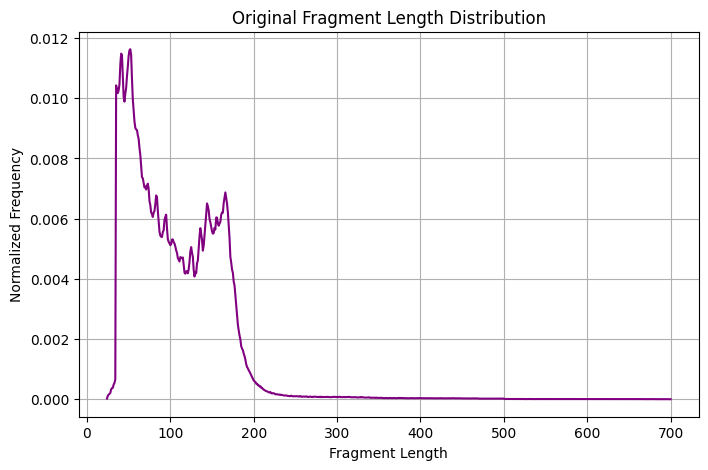

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load BED file and calculate fragment lengths
df = pd.read_csv('query.bed', sep='\t', header=None, low_memory=False)
frag_lengths = df.iloc[:, 2] - df.iloc[:, 1]
query_df = pd.DataFrame({'Fragment Length': frag_lengths})

# Compute normalized frequency of fragment lengths
frag_counter = Counter(frag_lengths)
total_frags = sum(frag_counter.values())
norm_freq = {length: count / total_frags for length, count in frag_counter.items()}

# Sort and prepare data for plotting
x_vals, y_vals = zip(*sorted(norm_freq.items()))
plot_df = pd.DataFrame({'Fragment Length': x_vals, 'Normalized Frequency': y_vals})

# Plot original distribution
plt.figure(figsize=(8, 5))
plt.plot(plot_df['Fragment Length'], plot_df['Normalized Frequency'], color='purple')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.title('Original Fragment Length Distribution')
plt.show()


##### **B. Adjusting the Query Dataset to Match the Reference Distribution**

To align the query dataset with the distribution of a reference dataset, both datasets are first partitioned into bins. Within each bin, we count how many elements fall into that range for both the query and reference datasets.

Next, we construct a new dataset by sampling `k` random elements from each corresponding bin in the query dataset, where `k` is the **minimum** count of values between the query and reference datasets in that bin. 

For instance, if the query dataset has 15 values in the interval [20, 30) and the reference dataset has 7, then we randomly pick 7 values from the query dataset that fall within that same range.

This bin-wise sampling method effectively normalizes or "rescales" the query dataset to approximate the distribution of the reference, producing a new dataset that reflects the reference structure more closely.


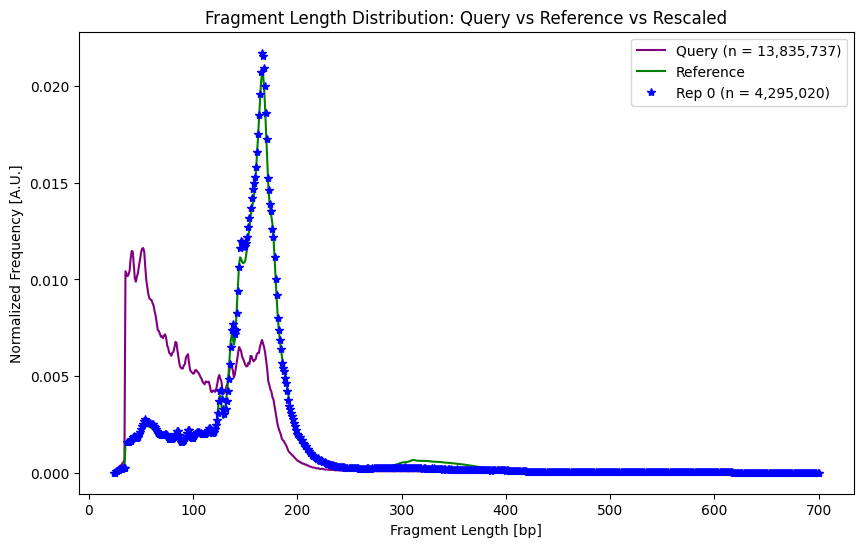

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load the reference histogram and query data (BED file)
ref_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['Fragment Length', 'Frequency'])
df = pd.read_csv('query.bed', sep='\t', header=None, low_memory=False)

# Calculate fragment lengths from the BED file
query_df = pd.DataFrame({'Fragment Length': df.iloc[:, 2] - df.iloc[:, 1]})

# Create bins based on reference fragment sizes
bin_edges = ref_df['Fragment Length'].values
query_df['bin'] = pd.cut(query_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1] + 1), labels=False, include_lowest=True)

# Resample the query data to match the reference distribution
subsampled_fragments = []
np.random.seed(42)

for i in range(len(ref_df)):
    bin_fragments = query_df[query_df['bin'] == i]
    if bin_fragments.empty:
        continue
    
    desired_fraction = ref_df.loc[i, 'Frequency']
    total_samples = int(desired_fraction * len(query_df) * 0.3346807)

    if total_samples < len(bin_fragments):
        sampled = bin_fragments.sample(n=total_samples, replace=False)
    else:
        sampled = bin_fragments
    
    subsampled_fragments.append(sampled)

# Merge all subsampled fragments
subsampled_df = pd.concat(subsampled_fragments)

# Plot the histograms
query_hist, _ = np.histogram(query_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1] + 1))
query_hist = query_hist / query_hist.sum()

subsampled_hist, _ = np.histogram(subsampled_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1] + 1))
subsampled_hist = subsampled_hist / subsampled_hist.sum()

# Plot the comparison 
plt.figure(figsize=(10, 6))
plt.plot(bin_edges, query_hist, label=f'Query (n = {len(query_df):,})', color='purple')
plt.plot(ref_df['Fragment Length'], ref_df['Frequency'], label='Reference', color='green')
plt.plot(bin_edges, subsampled_hist, label=f'Rep 0 (n = {len(subsampled_df):,})', marker='*', linestyle='None', color='blue')

plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.legend()
plt.title('Fragment Length Distribution: Query vs Reference vs Rescaled')
plt.show()
